bounded ReLU - ограниченный ReLU, где активация ограничена сверху порогом $a$ во избежание взрыва градиентов.$$f(x) = \min(a, \max(0, x))$$

# 1. Архитектура сети: полносвязный слой, BReLU, Sigmoid



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_classification

# --- БАЗОВЫЕ СЛОИ И АКТИВАЦИИ ---

class Dense:
    """
    Полносвязный слой (fully connected / linear).
    init='he' подходит для ReLU/BReLU, init='xavier' — для sigmoid/tanh.
    """
    def __init__(self, in_features, out_features, init='he'):
        if init == 'he':
            scale = np.sqrt(2.0 / in_features)
            self.W = np.random.randn(in_features, out_features) * scale
        elif init == 'xavier':
            limit = np.sqrt(6.0 / (in_features + out_features))
            self.W = np.random.uniform(-limit, limit, size=(in_features, out_features))
        else:
            raise ValueError("init должен быть 'he' или 'xavier'")

        self.b = np.zeros((1, out_features))
        self.x = None
        self.dW = None
        self.db = None

    def forward(self, x):
        self.x = x
        return np.dot(x, self.W) + self.b

    def backward(self, dout):
        # Градиенты по весам и смещениям.
        self.dW = np.dot(self.x.T, dout)
        self.db = np.sum(dout, axis=0, keepdims=True)

        # Градиент для передачи на предыдущий слой.
        dx = np.dot(dout, self.W.T)
        return dx


class BReLU:
    """
    Bounded ReLU: f(x) = min(a, max(0, x)).
    """
    def __init__(self, a=6.0):
        self.a = a
        self.x = None

    def forward(self, x):
        self.x = x
        return np.clip(x, 0, self.a)

    def backward(self, dout):
        dx = dout.copy()
        # Производная равна 0, если x <= 0 или x >= a, и равна 1 внутри интервала.
        dx[(self.x <= 0) | (self.x >= self.a)] = 0
        return dx


class Sigmoid:
    """
    Сигмоида для бинарной классификации и для скрытого слоя перцептрона.
    """
    def __init__(self):
        self.out = None

    def forward(self, x):
        x_clipped = np.clip(x, -500, 500)
        self.out = 1.0 / (1.0 + np.exp(-x_clipped))
        return self.out

    def backward(self, dout):
        return dout * self.out * (1.0 - self.out)


class Sequential:
    """
    Контейнер для последовательной сборки сети.
    """
    def __init__(self, *layers):
        self.layers = list(layers)

    def forward(self, x):
        out = x
        for layer in self.layers:
            out = layer.forward(out)
        return out

    def backward(self, dout):
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout


# 2. SGD с регулируемым batch size и NAdam как модификация Adam

В работе реализованы два оптимизатора:

1. `SGD` — обычный стохастический градиентный спуск. Размер мини-батча задается параметром `batch_size` в генераторе батчей.
2. `NAdam` — модификация Adam, где используются Momentum/Nesterov и адаптивное масштабирование шага через второй момент градиента, то есть RMSProp-подобная часть.

В обучении ниже оба оптимизатора реально участвуют в подборе гиперпараметров. Лучшая модель выбирается по `validation loss`, а не по тестовой выборке.

In [2]:
# --- ГЕНЕРАТОР БАТЧЕЙ ---

def get_batches(X, y, batch_size):
    """
    Генератор мини-батчей. Именно здесь регулируется размер batch size.
    """
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    for i in range(0, X.shape[0], batch_size):
        batch_idx = indices[i:i + batch_size]
        yield X[batch_idx], y[batch_idx]


# --- ОПТИМИЗАТОРЫ ---

class SGD:
    """
    Стохастический градиентный спуск.
    """
    def __init__(self, layers, lr=0.01):
        self.layers = layers
        self.lr = lr

    def step(self):
        for layer in self.layers:
            if hasattr(layer, 'W'):
                layer.W -= self.lr * layer.dW
                layer.b -= self.lr * layer.db


class NAdam:
    """
    NAdam: Nesterov Momentum + адаптивный шаг по второму моменту градиента.
    По смыслу это модификация Adam с RMSProp-подобной частью.
    """
    def __init__(self, layers, lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.layers = layers
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.m = {}
        self.v = {}
        self.t = 0

        for idx, layer in enumerate(self.layers):
            if hasattr(layer, 'W'):
                self.m[f'W{idx}'] = np.zeros_like(layer.W)
                self.v[f'W{idx}'] = np.zeros_like(layer.W)
                self.m[f'b{idx}'] = np.zeros_like(layer.b)
                self.v[f'b{idx}'] = np.zeros_like(layer.b)

    def step(self):
        self.t += 1
        for idx, layer in enumerate(self.layers):
            if hasattr(layer, 'W'):
                dW, db = layer.dW, layer.db

                # Обновление весов.
                self.m[f'W{idx}'] = self.beta1 * self.m[f'W{idx}'] + (1 - self.beta1) * dW
                self.v[f'W{idx}'] = self.beta2 * self.v[f'W{idx}'] + (1 - self.beta2) * (dW ** 2)

                m_hat_W = self.m[f'W{idx}'] / (1 - self.beta1 ** self.t)
                v_hat_W = self.v[f'W{idx}'] / (1 - self.beta2 ** self.t)
                m_nesterov_W = self.beta1 * m_hat_W + (1 - self.beta1) * dW / (1 - self.beta1 ** self.t)

                layer.W -= self.lr * m_nesterov_W / (np.sqrt(v_hat_W) + self.epsilon)

                # Обновление смещений.
                self.m[f'b{idx}'] = self.beta1 * self.m[f'b{idx}'] + (1 - self.beta1) * db
                self.v[f'b{idx}'] = self.beta2 * self.v[f'b{idx}'] + (1 - self.beta2) * (db ** 2)

                m_hat_b = self.m[f'b{idx}'] / (1 - self.beta1 ** self.t)
                v_hat_b = self.v[f'b{idx}'] / (1 - self.beta2 ** self.t)
                m_nesterov_b = self.beta1 * m_hat_b + (1 - self.beta1) * db / (1 - self.beta1 ** self.t)

                layer.b -= self.lr * m_nesterov_b / (np.sqrt(v_hat_b) + self.epsilon)


# 3. Генерация датасетов
Здесь используются встроенные инструменты scikit-learn для генерации двух датасетов из условия лабораторной работы.

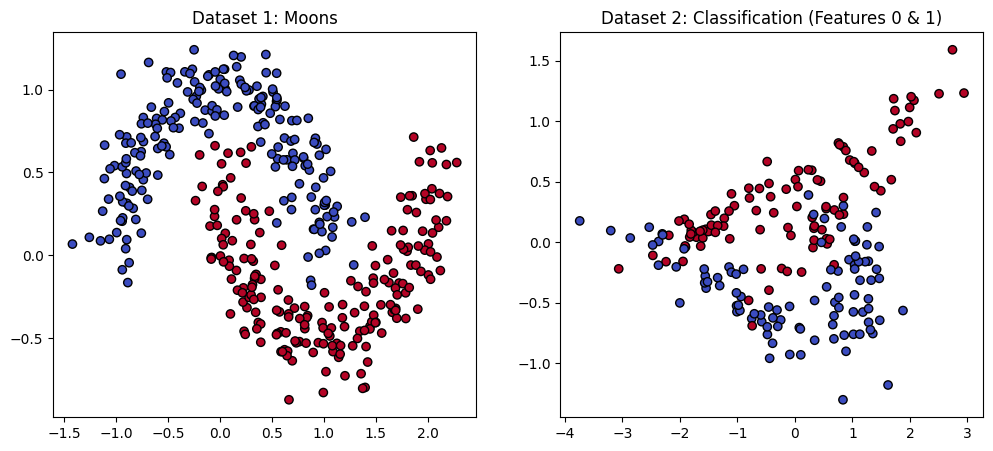

In [3]:
# --- ГЕНЕРАЦИЯ ДАННЫХ ---

ISU = 474321

# 1) датасет "луны" (нелинейно разделимые данные)
X_moons, y_moons = make_moons(
    n_samples=400,
    noise=0.15,
    random_state=ISU
)

# 2) датасет "классификация" (с избыточными и информативными признаками)
X_class, y_class = make_classification(
    n_samples=200,
    n_features=5,
    n_redundant=2,
    n_informative=2,
    n_clusters_per_class=2,
    n_classes=2,
    random_state=ISU
)

# графики
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='coolwarm', edgecolors='k')
plt.title('Dataset 1: Moons')

plt.subplot(1, 2, 2)
# для второго датасета выведем первые два признака (проекция)
plt.scatter(X_class[:, 0], X_class[:, 1], c=y_class, cmap='coolwarm', edgecolors='k')
plt.title('Dataset 2: Classification (Features 0 & 1)')

plt.show()

# 4. Обучение сети BReLU + Sigmoid с Cross-entropy

 Оба датасета делятся на три части: 60% — тренировочная выборка, 20% — валидационная выборка и 20% — тестовая выборка. Масштабирование признаков выполняется только по тренировочной части, чтобы не было утечки данных из validation/test.

В качестве функции потерь используется binary cross-entropy, потому что задача бинарной классификации решается через выходную Sigmoid-активацию. Гиперпараметры подбираются по валидационной ошибке: перебираются размер скрытого слоя, learning rate, batch size и оптимизатор. Лучшая модель выбирается не по тесту, а по минимальному validation loss. Тестовая выборка используется только в самом конце для честной финальной оценки.

In [4]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from IPython.display import display
import pandas as pd


def prepare_split(X, y, random_state):
    """
    Деление 60/20/20. random_state один и тот же для всех моделей,
    чтобы пункт 4 и пункт 5 сравнивались честно на одинаковых данных.
    """
    y = y.reshape(-1, 1).astype(float)

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=0.4,
        random_state=random_state,
        stratify=y
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.5,
        random_state=random_state,
        stratify=y_temp
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    return X_train, X_val, X_test, y_train, y_val, y_test, scaler


def binary_cross_entropy(y_true, y_pred):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return float(-np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)))


def binary_cross_entropy_grad(y_true, y_pred):
    """
    Градиент BCE по выходу sigmoid.
    Деление на размер батча нужно, чтобы масштаб градиента не зависел от batch size.
    """
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return (-(y_true / y_pred) + (1 - y_true) / (1 - y_pred)) / y_true.shape[0]


def predict_proba(model, X):
    return model.forward(X)


def predict_class(model, X, threshold=0.5):
    return (predict_proba(model, X) >= threshold).astype(int)


def accuracy_from_model(model, X, y):
    return accuracy_score(y.astype(int).ravel(), predict_class(model, X).ravel())


def get_model_state(model):
    state = []
    for layer in model.layers:
        if hasattr(layer, 'W'):
            state.append((layer.W.copy(), layer.b.copy()))
    return state


def set_model_state(model, state):
    j = 0
    for layer in model.layers:
        if hasattr(layer, 'W'):
            layer.W = state[j][0].copy()
            layer.b = state[j][1].copy()
            j += 1


def make_optimizer(name, layers, lr):
    if name == 'sgd':
        return SGD(layers, lr=lr)
    if name == 'nadam':
        return NAdam(layers, lr=lr)
    raise ValueError("optimizer должен быть 'sgd' или 'nadam'")


def train_with_cross_entropy(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    lr,
    batch_size,
    optimizer_name='nadam',
    epochs=350,
    patience=45
):
    optimizer = make_optimizer(optimizer_name, model.layers, lr)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    best_state = get_model_state(model)
    best_val_loss = np.inf
    best_epoch = 0
    wait = 0

    for epoch in range(epochs):
        for X_batch, y_batch in get_batches(X_train, y_train, batch_size):
            y_pred = model.forward(X_batch)
            grad = binary_cross_entropy_grad(y_batch, y_pred)
            model.backward(grad)
            optimizer.step()

        train_pred = model.forward(X_train)
        val_pred = model.forward(X_val)
        train_loss = binary_cross_entropy(y_train, train_pred)
        val_loss = binary_cross_entropy(y_val, val_pred)
        train_acc = accuracy_from_model(model, X_train, y_train)
        val_acc = accuracy_from_model(model, X_val, y_val)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_state = get_model_state(model)
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    set_model_state(model, best_state)
    return history, best_epoch, best_val_loss


def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test):
    test_pred = predict_class(model, X_test)
    return {
        'train_accuracy': accuracy_from_model(model, X_train, y_train),
        'val_accuracy': accuracy_from_model(model, X_val, y_val),
        'test_accuracy': accuracy_score(y_test.astype(int).ravel(), test_pred.ravel()),
        'test_precision': precision_score(y_test.astype(int).ravel(), test_pred.ravel(), zero_division=0),
        'test_recall': recall_score(y_test.astype(int).ravel(), test_pred.ravel(), zero_division=0),
        'test_f1': f1_score(y_test.astype(int).ravel(), test_pred.ravel(), zero_division=0),
        'confusion_matrix': confusion_matrix(y_test.astype(int).ravel(), test_pred.ravel())
    }


def build_brelu_sigmoid_network(input_dim, hidden_units):
    """
    Модель для пункта 4: скрытый слой с BReLU + выходная Sigmoid.
    """
    return Sequential(
        Dense(input_dim, hidden_units, init='he'),
        BReLU(a=6.0),
        Dense(hidden_units, 1, init='xavier'),
        Sigmoid()
    )


def tune_model(X, y, dataset_name, model_name, builder, split_random_state, init_seed_offset=0):
    X_train, X_val, X_test, y_train, y_val, y_test, scaler = prepare_split(X, y, split_random_state)

    # В сетке есть и NAdam, и SGD. Так видно, что оба оптимизатора реально проверялись.
    grid = [
        (8, 0.01, 16, 'nadam'),
        (16, 0.01, 32, 'nadam'),
        (16, 0.005, 32, 'nadam'),
        (32, 0.005, 32, 'nadam'),
        (16, 0.05, 32, 'sgd'),
    ]

    best = None
    all_results = []

    for run_id, (hidden_units, lr, batch_size, optimizer_name) in enumerate(grid):
        np.random.seed(split_random_state + init_seed_offset + run_id)
        model = builder(X_train.shape[1], hidden_units)

        history, best_epoch, best_val_loss = train_with_cross_entropy(
            model,
            X_train,
            y_train,
            X_val,
            y_val,
            lr=lr,
            batch_size=batch_size,
            optimizer_name=optimizer_name
        )

        metrics = evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test)
        row = {
            'model_name': model_name,
            'dataset': dataset_name,
            'optimizer': optimizer_name,
            'hidden_units': hidden_units,
            'lr': lr,
            'batch_size': batch_size,
            'best_epoch': best_epoch,
            'best_val_loss': best_val_loss,
            **metrics,
            'model': model,
            'history': history,
            'scaler': scaler,
            'split': (X_train, X_val, X_test, y_train, y_val, y_test)
        }

        all_results.append(row)
        if best is None or row['best_val_loss'] < best['best_val_loss']:
            best = row

    return best, all_results


def results_to_table(results):
    cols = [
        'model_name', 'dataset', 'optimizer', 'hidden_units', 'lr', 'batch_size',
        'best_epoch', 'best_val_loss', 'train_accuracy', 'val_accuracy',
        'test_accuracy', 'test_precision', 'test_recall', 'test_f1'
    ]
    table = pd.DataFrame([{col: row[col] for col in cols} for row in results])
    numeric_cols = ['best_val_loss', 'train_accuracy', 'val_accuracy', 'test_accuracy', 'test_precision', 'test_recall', 'test_f1']
    table[numeric_cols] = table[numeric_cols].round(4)
    return table.sort_values(['dataset', 'best_val_loss']).reset_index(drop=True)


def print_best_result(title, result):
    print(title)
    print('Модель:', result['model_name'])
    print('Датасет:', result['dataset'])
    print('Лучшие гиперпараметры:')
    print('optimizer =', result['optimizer'])
    print('hidden_units =', result['hidden_units'])
    print('lr =', result['lr'])
    print('batch_size =', result['batch_size'])
    print('best_epoch =', result['best_epoch'])
    print('val_loss =', round(result['best_val_loss'], 4))
    print('train_accuracy =', round(result['train_accuracy'], 4))
    print('val_accuracy =', round(result['val_accuracy'], 4))
    print('test_accuracy =', round(result['test_accuracy'], 4))
    print('test_precision =', round(result['test_precision'], 4))
    print('test_recall =', round(result['test_recall'], 4))
    print('test_f1 =', round(result['test_f1'], 4))
    print('confusion_matrix:')
    print(result['confusion_matrix'])
    print()


def plot_training_history(result, title):
    history = result['history']
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='train loss')
    plt.plot(history['val_loss'], label='validation loss')
    plt.title(title + ': loss')
    plt.xlabel('epoch')
    plt.ylabel('cross-entropy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='train accuracy')
    plt.plot(history['val_acc'], label='validation accuracy')
    plt.title(title + ': accuracy')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.legend()

    plt.show()


## Запуск обучения для пункта 4

Ниже сеть BReLU + Sigmoid обучается отдельно на двух датасетах. Для каждого датасета выполняется подбор гиперпараметров. После выбора лучшей модели выводятся accuracy, precision, recall, F1-score и confusion matrix на тестовой выборке.

Пункт 4. BReLU + Sigmoid
Модель: BReLU + Sigmoid
Датасет: make_moons
Лучшие гиперпараметры:
optimizer = nadam
hidden_units = 16
lr = 0.005
batch_size = 32
best_epoch = 309
val_loss = 0.083
train_accuracy = 1.0
val_accuracy = 0.9625
test_accuracy = 0.9625
test_precision = 0.9512
test_recall = 0.975
test_f1 = 0.963
confusion_matrix:
[[38  2]
 [ 1 39]]

Пункт 4. BReLU + Sigmoid
Модель: BReLU + Sigmoid
Датасет: make_classification
Лучшие гиперпараметры:
optimizer = nadam
hidden_units = 16
lr = 0.01
batch_size = 32
best_epoch = 31
val_loss = 0.279
train_accuracy = 0.8417
val_accuracy = 0.875
test_accuracy = 0.925
test_precision = 0.9474
test_recall = 0.9
test_f1 = 0.9231
confusion_matrix:
[[19  1]
 [ 2 18]]

Таблица подбора гиперпараметров для пункта 4:


,model_name,dataset,optimizer,hidden_units,lr,batch_size,best_epoch,best_val_loss,train_accuracy,val_accuracy,test_accuracy,test_precision,test_recall,test_f1
0,BReLU + Sigmoid,make_classification,nadam,16,0.010,32,31,0.2790,0.8417,0.8750,0.9250,0.9474,0.900,0.9231
1,BReLU + Sigmoid,make_classification,nadam,8,0.010,16,5,0.2830,0.8083,0.9250,0.8750,0.8571,0.900,0.8780
2,BReLU + Sigmoid,make_classification,nadam,16,0.005,32,57,0.2923,0.8417,0.8750,0.9000,0.9000,0.900,0.9000
3,BReLU + Sigmoid,make_classification,sgd,16,0.050,32,262,0.2966,0.8750,0.9000,0.9250,0.9474,0.900,0.9231
4,BReLU + Sigmoid,make_classification,nadam,32,0.005,32,11,0.3044,0.8167,0.8500,0.9000,0.9000,0.900,0.9000
5,BReLU + Sigmoid,make_moons,nadam,16,0.005,32,309,0.0830,1.0000,0.9625,0.9625,0.9512,0.975,0.9630
6,BReLU + Sigmoid,make_moons,nadam,8,0.010,16,142,0.0966,1.0000,0.9625,0.9625,0.9512,0.975,0.9630
7,BReLU + Sigmoid,make_moons,nadam,16,0.010,32,141,0.1055,1.0000,0.9625,0.9625,0.9512,0.975,0.9630
8,BReLU + Sigmoid,make_moons,nadam,32,0.005,32,151,0.1213,1.0000,0.9625,0.9625,0.9512,0.975,0.9630
9,BReLU + Sigmoid,make_moons,sgd,16,0.050,32,350,0.1895,0.9792,0.9000,0.9500,0.9286,0.975,0.9512


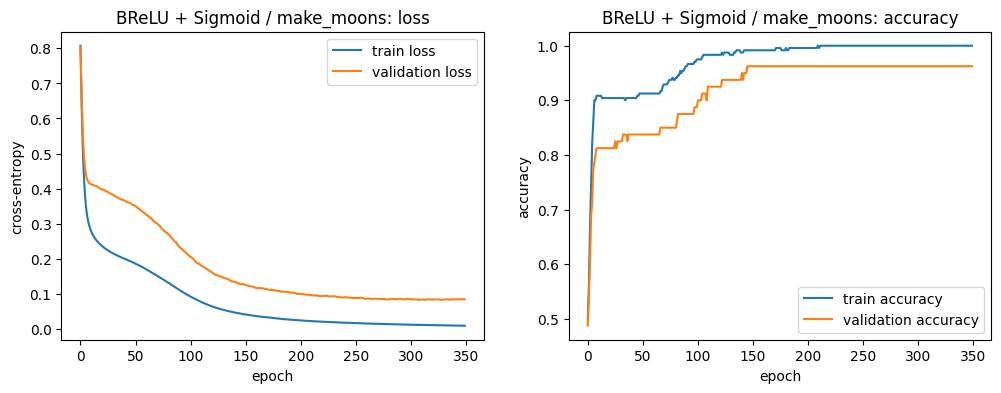

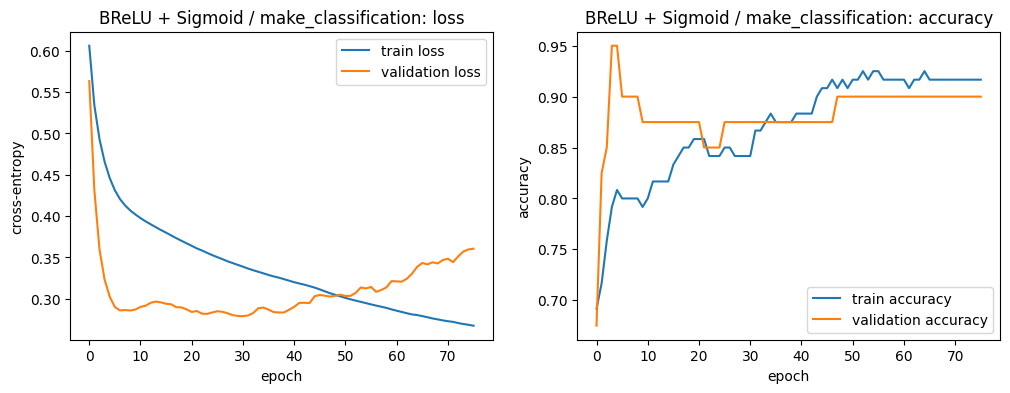

In [5]:

brelu_moons_best, brelu_moons_all = tune_model(
    X_moons,
    y_moons,
    dataset_name='make_moons',
    model_name='BReLU + Sigmoid',
    builder=build_brelu_sigmoid_network,
    split_random_state=ISU,
    init_seed_offset=0
)

brelu_class_best, brelu_class_all = tune_model(
    X_class,
    y_class,
    dataset_name='make_classification',
    model_name='BReLU + Sigmoid',
    builder=build_brelu_sigmoid_network,
    split_random_state=ISU,
    init_seed_offset=10000
)

print_best_result('Пункт 4. BReLU + Sigmoid', brelu_moons_best)
print_best_result('Пункт 4. BReLU + Sigmoid', brelu_class_best)

print('Таблица подбора гиперпараметров для пункта 4:')
display(results_to_table(brelu_moons_all + brelu_class_all))

plot_training_history(brelu_moons_best, 'BReLU + Sigmoid / make_moons')
plot_training_history(brelu_class_best, 'BReLU + Sigmoid / make_classification')


# 5. Перцептрон с одним скрытым слоем

В этом блоке реализуется отдельный перцептрон с одним скрытым слоем. Чтобы пункт 5 не повторял пункт 4, в скрытом слое здесь используется `Sigmoid`, а не `BReLU`.

Структура обучения остается такой же: binary cross-entropy, разбиение 60/20/20, подбор гиперпараметров по validation loss и финальная проверка на test. Для честного сравнения используется такое же train/validation/test-разбиение, как в пункте 4.

Пункт 5. Перцептрон с одним скрытым слоем
Модель: One hidden layer perceptron
Датасет: make_moons
Лучшие гиперпараметры:
optimizer = sgd
hidden_units = 16
lr = 0.05
batch_size = 32
best_epoch = 76
val_loss = 0.3923
train_accuracy = 0.8917
val_accuracy = 0.8
test_accuracy = 0.8875
test_precision = 0.8605
test_recall = 0.925
test_f1 = 0.8916
confusion_matrix:
[[34  6]
 [ 3 37]]

Пункт 5. Перцептрон с одним скрытым слоем
Модель: One hidden layer perceptron
Датасет: make_classification
Лучшие гиперпараметры:
optimizer = nadam
hidden_units = 16
lr = 0.01
batch_size = 32
best_epoch = 196
val_loss = 0.2777
train_accuracy = 0.8833
val_accuracy = 0.875
test_accuracy = 0.925
test_precision = 0.9474
test_recall = 0.9
test_f1 = 0.9231
confusion_matrix:
[[19  1]
 [ 2 18]]

Таблица подбора гиперпараметров для пункта 5:


,model_name,dataset,optimizer,hidden_units,lr,batch_size,best_epoch,best_val_loss,train_accuracy,val_accuracy,test_accuracy,test_precision,test_recall,test_f1
0,One hidden layer perceptron,make_classification,nadam,16,0.010,32,196,0.2777,0.8833,0.8750,0.9250,0.9474,0.900,0.9231
1,One hidden layer perceptron,make_classification,nadam,16,0.005,32,197,0.2951,0.8000,0.8750,0.8750,0.8571,0.900,0.8780
2,One hidden layer perceptron,make_classification,nadam,32,0.005,32,169,0.3020,0.8000,0.9000,0.8750,0.8571,0.900,0.8780
3,One hidden layer perceptron,make_classification,nadam,8,0.010,16,114,0.3022,0.8083,0.8750,0.8750,0.8571,0.900,0.8780
4,One hidden layer perceptron,make_classification,sgd,16,0.050,32,320,0.3027,0.8000,0.9000,0.8750,0.8571,0.900,0.8780
5,One hidden layer perceptron,make_moons,nadam,16,0.010,32,10,0.3923,0.8875,0.8000,0.8875,0.8605,0.925,0.8916
6,One hidden layer perceptron,make_moons,sgd,16,0.050,32,76,0.3923,0.8917,0.8000,0.8875,0.8605,0.925,0.8916
7,One hidden layer perceptron,make_moons,nadam,32,0.005,32,20,0.3933,0.8875,0.8000,0.8750,0.8409,0.925,0.8810
8,One hidden layer perceptron,make_moons,nadam,16,0.005,32,27,0.3978,0.8875,0.8000,0.8875,0.8605,0.925,0.8916
9,One hidden layer perceptron,make_moons,nadam,8,0.010,16,10,0.4042,0.8958,0.8125,0.8750,0.8409,0.925,0.8810


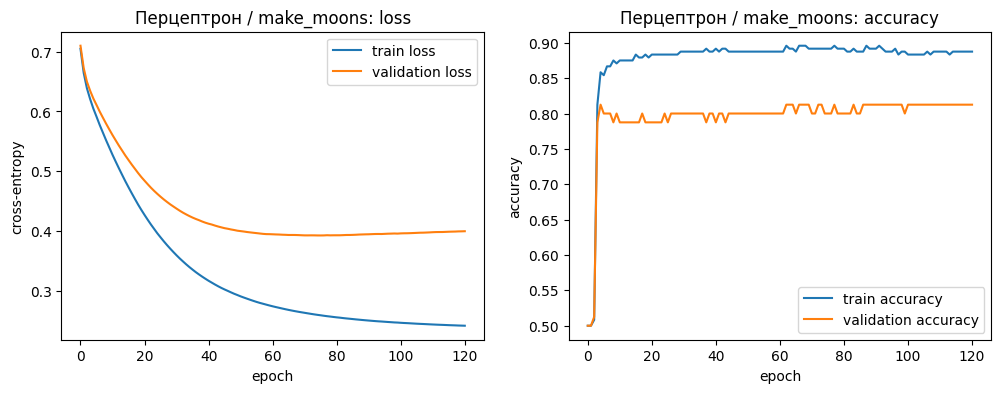

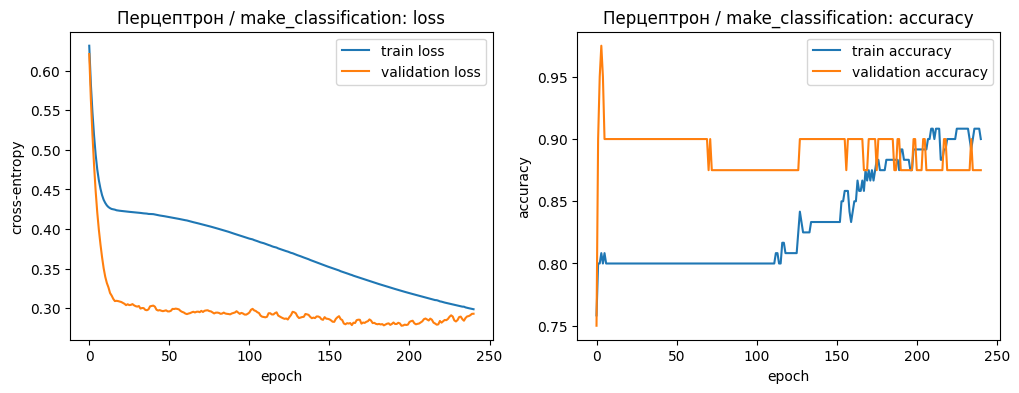

In [6]:

class OneHiddenLayerPerceptron:
    """
    Перцептрон с одним скрытым слоем.
    Отличие от модели пункта 4: скрытая активация здесь Sigmoid, а не BReLU.
    """
    def __init__(self, input_dim, hidden_units):
        self.model = Sequential(
            Dense(input_dim, hidden_units, init='xavier'),
            Sigmoid(),
            Dense(hidden_units, 1, init='xavier'),
            Sigmoid()
        )
        self.layers = self.model.layers

    def forward(self, x):
        return self.model.forward(x)

    def backward(self, dout):
        return self.model.backward(dout)


def build_one_hidden_layer_perceptron(input_dim, hidden_units):
    return OneHiddenLayerPerceptron(input_dim, hidden_units)


perceptron_moons_best, perceptron_moons_all = tune_model(
    X_moons,
    y_moons,
    dataset_name='make_moons',
    model_name='One hidden layer perceptron',
    builder=build_one_hidden_layer_perceptron,
    split_random_state=ISU,
    init_seed_offset=20000
)

perceptron_class_best, perceptron_class_all = tune_model(
    X_class,
    y_class,
    dataset_name='make_classification',
    model_name='One hidden layer perceptron',
    builder=build_one_hidden_layer_perceptron,
    split_random_state=ISU,
    init_seed_offset=30000
)

print_best_result('Пункт 5. Перцептрон с одним скрытым слоем', perceptron_moons_best)
print_best_result('Пункт 5. Перцептрон с одним скрытым слоем', perceptron_class_best)

print('Таблица подбора гиперпараметров для пункта 5:')
display(results_to_table(perceptron_moons_all + perceptron_class_all))

plot_training_history(perceptron_moons_best, 'Перцептрон / make_moons')
plot_training_history(perceptron_class_best, 'Перцептрон / make_classification')


# вывод

В работе вручную реализованы полносвязный слой, BReLU, Sigmoid, прямой проход и обратное распространение ошибки. Для обучения используется binary cross-entropy, так как решается задача бинарной классификации с выходной Sigmoid-активацией.

Данные делятся на train/validation/test в пропорции 60/20/20. Масштабирование признаков выполняется только по тренировочной выборке, без утечки данных из validation/test.

Гиперпараметры подбираются по validation loss. В подборе участвуют разные размеры скрытого слоя, learning rate, batch size, а также два оптимизатора: SGD и NAdam.